# Logistic analysis of learned edge selection

This notebook treats every training edge as one sample and asks which observable edge properties best explain the final hard-mask decision. It is a post-hoc association analysis; it does not train a new mask and does not establish causality.

Primary setting: within-user percentile features, users with both selected and unselected edges, and user-grouped out-of-fold evaluation.

In [1]:
from pathlib import Path
import gc
import time
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.stats import norm, rankdata

try:
    import sklearn
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
    from sklearn.model_selection import GroupKFold
    try:
        from sklearn.model_selection import StratifiedGroupKFold
    except ImportError:
        StratifiedGroupKFold = None
    from sklearn.preprocessing import StandardScaler
except ImportError as error:
    raise RuntimeError(
        'This notebook requires scikit-learn. Install it in the explainable kernel first.'
    ) from error

if int(torch.__version__.split('.')[0]) < 2:
    raise RuntimeError('Select the explainable kernel with PyTorch >= 2.')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:.6f}')

SEED = 999
N_SPLITS = 5
N_BOOTSTRAP = 1000
RUN_ROBUSTNESS = True
RUN_DEGREE4_SENSITIVITY = False
RUN_NAME = 'PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39'

def find_src_dir():
    cwd = Path.cwd()
    candidates = [cwd, cwd / 'src', *cwd.parents]
    for candidate in candidates:
        if (candidate / 'saved').is_dir() and (candidate / 'mask_analysis').is_dir():
            return candidate
    raise FileNotFoundError('Cannot locate PGL/src from the current directory.')

SRC_DIR = find_src_dir()
ANALYSIS_PATH = SRC_DIR / 'saved' / f'{RUN_NAME}-analysis.pt'
CHECKPOINT_PATH = SRC_DIR / 'saved' / f'{RUN_NAME}.pth'
assert ANALYSIS_PATH.is_file(), ANALYSIS_PATH
assert CHECKPOINT_PATH.is_file(), CHECKPOINT_PATH

print('PyTorch:', torch.__version__)
print('scikit-learn:', sklearn.__version__)
print('Analysis:', ANALYSIS_PATH)
print('Checkpoint:', CHECKPOINT_PATH)

PyTorch: 2.2.1+cu118
scikit-learn: 1.7.2
Analysis: c:\study\Master_papers\code\multimodal_RS\PGL\src\saved\PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39-analysis.pt
Checkpoint: c:\study\Master_papers\code\multimodal_RS\PGL\src\saved\PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39.pth


## 1. Reconstruct the edge-level analysis table

`mask_logit` and `mask_probability` are retained only for validation. They are deliberately excluded from all logistic inputs because they directly determine the target.

In [2]:
analysis = torch.load(ANALYSIS_PATH, map_location='cpu', weights_only=False)
metadata = analysis['metadata']
mask_data = analysis['masks']['masked_branch']

user_ids = analysis['ui_edges']['user_ids'].long()
item_ids = analysis['ui_edges']['item_ids'].long()
mask_logits = mask_data['logits'].float()
mask_probability = mask_data['probabilities'].float()
selected = mask_data['selected_at_keep_ratio'].bool()

n_edges = metadata['num_interactions']
n_users = metadata['num_users']
n_items = metadata['num_items']
expected_selected = int(n_edges * metadata['mask_keep_ratio'])

assert len(user_ids) == len(item_ids) == len(mask_logits) == len(selected) == n_edges
assert int(user_ids.min()) >= 0 and int(user_ids.max()) < n_users
assert int(item_ids.min()) >= 0 and int(item_ids.max()) < n_items
assert torch.allclose(mask_probability, torch.sigmoid(mask_logits), atol=1e-7)
assert int(selected.sum()) == expected_selected

edge_df = pd.DataFrame({
    'edge_id': np.arange(n_edges, dtype=np.int64),
    'user_id': user_ids.numpy(),
    'item_id': item_ids.numpy(),
    'mask_logit': mask_logits.numpy(),
    'mask_probability': mask_probability.numpy(),
    'selected': selected.numpy(),
})

del analysis, mask_data, user_ids, item_ids, mask_logits, mask_probability, selected
gc.collect()

print(f'Edges: {len(edge_df):,}')
print(f'Selected: {edge_df.selected.sum():,} ({edge_df.selected.mean():.2%})')
print(f'Unselected: {(~edge_df.selected).sum():,}')
print(f'Users: {edge_df.user_id.nunique():,}; items: {edge_df.item_id.nunique():,}')
edge_df.head()

Edges: 118,551
Selected: 35,565 (30.00%)
Unselected: 82,986
Users: 19,445; items: 7,047


,edge_id,user_id,item_id,mask_logit,mask_probability,selected
0,0,0,0,-0.859371,0.297471,True
1,1,0,1587,-0.977345,0.273419,False
2,2,0,1879,-0.875220,0.294169,True
3,3,1,0,-0.821523,0.305441,True
4,4,1,1434,-0.836464,0.302280,True


In [3]:
user_degree = np.bincount(edge_df.user_id, minlength=n_users)
item_degree = np.bincount(edge_df.item_id, minlength=n_items)
edge_df['user_degree'] = user_degree[edge_df.user_id.to_numpy()]
edge_df['item_degree'] = item_degree[edge_df.item_id.to_numpy()]
edge_df['log_item_degree'] = np.log1p(edge_df.item_degree)

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
state = checkpoint['model_state_dict']
required_keys = {
    'second_user_image.weight', 'second_user_text.weight',
    'image_embedding.weight', 'text_embedding.weight',
    'image_trs.weight', 'image_trs.bias',
    'text_trs.weight', 'text_trs.bias',
}
missing_keys = required_keys.difference(state)
assert not missing_keys, f'Missing checkpoint keys: {sorted(missing_keys)}'

with torch.no_grad():
    user_visual = F.normalize(state['second_user_image.weight'].float(), dim=1)
    user_textual = F.normalize(state['second_user_text.weight'].float(), dim=1)
    item_visual = F.normalize(
        F.linear(
            state['image_embedding.weight'].float(),
            state['image_trs.weight'].float(),
            state['image_trs.bias'].float(),
        ),
        dim=1,
    )
    item_textual = F.normalize(
        F.linear(
            state['text_embedding.weight'].float(),
            state['text_trs.weight'].float(),
            state['text_trs.bias'].float(),
        ),
        dim=1,
    )

assert user_visual.shape == user_textual.shape == (n_users, 64)
assert item_visual.shape == item_textual.shape == (n_items, 64)

edge_users = torch.from_numpy(edge_df.user_id.to_numpy(dtype=np.int64))
edge_items = torch.from_numpy(edge_df.item_id.to_numpy(dtype=np.int64))
with torch.no_grad():
    visual_similarity = (user_visual[edge_users] * item_visual[edge_items]).sum(dim=1)
    textual_similarity = (user_textual[edge_users] * item_textual[edge_items]).sum(dim=1)

edge_df['visual_similarity'] = visual_similarity.numpy()
edge_df['textual_similarity'] = textual_similarity.numpy()
assert np.isfinite(edge_df[[
    'log_item_degree', 'visual_similarity', 'textual_similarity'
]].to_numpy()).all()

del checkpoint, state, edge_users, edge_items, visual_similarity, textual_similarity
del user_visual, user_textual, item_visual, item_textual
gc.collect()

edge_df.groupby('selected')[[
    'item_degree', 'visual_similarity', 'textual_similarity'
]].agg(['count', 'mean', 'median'])

item_degree                     visual_similarity                    \
               count      mean    median             count     mean   median   
selected                                                                       
False          82986 66.234268 35.000000             82986 0.464973 0.478302   
True           35565 48.631520 22.000000             35565 0.570282 0.592044   

         textual_similarity                    
                      count     mean   median  
selected                                       
False                 82986 0.485102 0.496551  
True                  35565 0.607562 0.620418

In [4]:
def within_user_percentile(frame, value_column):
    grouped = frame.groupby('user_id')[value_column]
    ranks = grouped.rank(method='average')
    sizes = grouped.transform('size')
    percentile = (ranks - 1.0) / (sizes - 1.0)
    return percentile.where(sizes.gt(1), 0.5)

edge_df['degree_percentile_user'] = within_user_percentile(edge_df, 'item_degree')
edge_df['visual_percentile_user'] = within_user_percentile(edge_df, 'visual_similarity')
edge_df['textual_percentile_user'] = within_user_percentile(edge_df, 'textual_similarity')

label_variety = edge_df.groupby('user_id').selected.nunique()
mixed_users = label_variety.index[label_variety.eq(2)]
edge_df['mixed_user'] = edge_df.user_id.isin(mixed_users)

feature_columns = [
    'log_item_degree', 'visual_similarity', 'textual_similarity',
    'degree_percentile_user', 'visual_percentile_user', 'textual_percentile_user',
]
assert edge_df[feature_columns].notna().all().all()
assert np.isfinite(edge_df[feature_columns].to_numpy()).all()

user_group_summary = pd.Series({
    'all_users': edge_df.user_id.nunique(),
    'mixed_users': len(mixed_users),
    'selected_only_users': int((edge_df.groupby('user_id').selected.agg(['all', 'any'])['all']).sum()),
    'unselected_only_users': int((~edge_df.groupby('user_id').selected.agg(['all', 'any'])['any']).sum()),
})
user_group_summary

all_users                19445
mixed_users              12922
selected_only_users       1836
unselected_only_users     4687
dtype: int64

## 2. Model definitions and grouped cross-validation

All base features are standardized using the training fold only. Interactions are formed after standardization. `M_DV` and `M_DT` are supplementary drop-one models. A very weak L2 penalty (`C=1e6`) approximates unpenalized logistic regression while remaining compatible across scikit-learn versions.

In [6]:
MODEL_FEATURES = OrderedDict([
    ('M0', []),
    ('M1_degree', ['D']),
    ('M2_visual', ['V']),
    ('M3_textual', ['T']),
    ('M4_visual_textual', ['V', 'T']),
    ('M5_degree_visual_textual', ['D', 'V', 'T']),
    ('M6_interactions', ['D', 'V', 'T', 'D_x_V', 'D_x_T']),
    ('M_DV', ['D', 'V']),
    ('M_DT', ['D', 'T']),
])
MAIN_MODELS = list(MODEL_FEATURES)[:7]

FEATURE_SCOPES = {
    'within_user': {
        'D': 'degree_percentile_user',
        'V': 'visual_percentile_user',
        'T': 'textual_percentile_user',
    },
    'global': {
        'D': 'log_item_degree',
        'V': 'visual_similarity',
        'T': 'textual_similarity',
    },
}

experiment_specs = [
    {'name': 'within_mixed', 'scope': 'within_user', 'mixed_only': True, 'min_user_degree': None},
]
if RUN_ROBUSTNESS:
    experiment_specs.extend([
        {'name': 'global_mixed', 'scope': 'global', 'mixed_only': True, 'min_user_degree': None},
        {'name': 'within_all', 'scope': 'within_user', 'mixed_only': False, 'min_user_degree': None},
        {'name': 'global_all', 'scope': 'global', 'mixed_only': False, 'min_user_degree': None},
    ])
if RUN_DEGREE4_SENSITIVITY:
    experiment_specs.append({
        'name': 'within_mixed_degree4',
        'scope': 'within_user',
        'mixed_only': True,
        'min_user_degree': 4,
    })

pd.DataFrame(experiment_specs)

,name,scope,mixed_only,min_user_degree
0,within_mixed,within_user,True,None
1,global_mixed,global,True,None
2,within_all,within_user,False,None
3,global_all,global,False,None


In [10]:
def make_splitter():
    if StratifiedGroupKFold is not None:
        return StratifiedGroupKFold(
            n_splits=N_SPLITS, shuffle=True, random_state=SEED
        )
    print('StratifiedGroupKFold unavailable; falling back to GroupKFold.')
    return GroupKFold(n_splits=N_SPLITS)

def make_logistic():
    return LogisticRegression(
        penalty='l2', C=1e6, solver='lbfgs', max_iter=2000,
        class_weight=None, random_state=SEED,
    )

def standardized_design(base_frame, scaler):
    standardized = scaler.transform(base_frame[['D', 'V', 'T']])
    design = pd.DataFrame(standardized, columns=['D', 'V', 'T'], index=base_frame.index)
    design['D_x_V'] = design['D'] * design['V']
    design['D_x_T'] = design['D'] * design['T']
    return design

def run_experiment(spec):
    data = edge_df.copy()
    if spec['mixed_only']:
        data = data.loc[data.mixed_user]
    if spec['min_user_degree'] is not None:
        data = data.loc[data.user_degree.ge(spec['min_user_degree'])]
    data = data.reset_index(drop=True)

    source_columns = FEATURE_SCOPES[spec['scope']]
    base = data[[source_columns['D'], source_columns['V'], source_columns['T']]].copy()
    base.columns = ['D', 'V', 'T']
    labels = data.selected.astype(np.int8).to_numpy()
    groups = data.user_id.to_numpy()

    splitter = make_splitter()
    split_iterator = splitter.split(base, labels, groups)
    predictions = {model_name: np.full(len(data), np.nan) for model_name in MODEL_FEATURES}
    fold_rows = []

    for fold, (train_index, validation_index) in enumerate(split_iterator, start=1):
        y_train = labels[train_index]
        y_validation = labels[validation_index]
        if np.unique(y_train).size != 2 or np.unique(y_validation).size != 2:
            raise RuntimeError(f'Fold {fold} does not contain both target classes.')

        scaler = StandardScaler().fit(base.iloc[train_index])
        train_design = standardized_design(base.iloc[train_index], scaler)
        validation_design = standardized_design(base.iloc[validation_index], scaler)

        for model_name, columns in MODEL_FEATURES.items():
            if not columns:
                validation_probability = np.full(len(validation_index), y_train.mean())
            else:
                model = make_logistic()
                model.fit(train_design[columns], y_train)
                validation_probability = model.predict_proba(
                    validation_design[columns]
                )[:, 1]

            predictions[model_name][validation_index] = validation_probability
            fold_rows.append({
                'experiment': spec['name'],
                'fold': fold,
                'model': model_name,
                'edges': len(validation_index),
                'selected_rate': y_validation.mean(),
                'roc_auc': roc_auc_score(y_validation, validation_probability),
                'pr_auc': average_precision_score(y_validation, validation_probability),
            })

    for model_name, values in predictions.items():
        assert np.isfinite(values).all(), f'Missing OOF predictions for {model_name}'

    return data, base, labels, predictions, pd.DataFrame(fold_rows)

In [11]:
experiment_data = {}
experiment_base = {}
experiment_labels = {}
oof_predictions = {}
fold_metric_frames = []

start_time = time.time()
for spec in experiment_specs:
    experiment_start = time.time()
    data, base, labels, predictions, fold_metrics = run_experiment(spec)
    name = spec['name']
    experiment_data[name] = data
    experiment_base[name] = base
    experiment_labels[name] = labels
    oof_predictions[name] = predictions
    fold_metric_frames.append(fold_metrics)
    print(
        f'{name}: {len(data):,} edges, {data.user_id.nunique():,} users, '
        f'{time.time() - experiment_start:.1f}s'
    )

cv_fold_metrics = pd.concat(fold_metric_frames, ignore_index=True)
print(f'Total cross-validation time: {time.time() - start_time:.1f}s')

within_mixed: 86,114 edges, 12,922 users, 6.6s
global_mixed: 86,114 edges, 12,922 users, 6.8s
within_all: 118,551 edges, 19,445 users, 9.4s
global_all: 118,551 edges, 19,445 users, 9.7s
Total cross-validation time: 32.6s


## 3. Out-of-fold predictive performance

ROC-AUC is the main metric. PR-AUC is included because only 30% of all edges are selected. All pooled scores below are computed exclusively from out-of-fold predictions.

In [12]:
fold_summary = (
    cv_fold_metrics.groupby(['experiment', 'model'])
    .agg(
        fold_roc_auc_mean=('roc_auc', 'mean'),
        fold_roc_auc_std=('roc_auc', 'std'),
        fold_pr_auc_mean=('pr_auc', 'mean'),
        fold_pr_auc_std=('pr_auc', 'std'),
    )
    .reset_index()
)

pooled_rows = []
for experiment_name, predictions in oof_predictions.items():
    labels = experiment_labels[experiment_name]
    for model_name, probability in predictions.items():
        pooled_rows.append({
            'experiment': experiment_name,
            'model': model_name,
            'pooled_roc_auc': roc_auc_score(labels, probability),
            'pooled_pr_auc': average_precision_score(labels, probability),
        })
pooled_summary = pd.DataFrame(pooled_rows)
performance_summary = fold_summary.merge(
    pooled_summary, on=['experiment', 'model'], how='inner'
)

primary_performance = (
    performance_summary.loc[
        performance_summary.experiment.eq('within_mixed')
        & performance_summary.model.isin(MAIN_MODELS)
    ]
    .set_index('model')
    .reindex(MAIN_MODELS)
)
primary_performance

,experiment,fold_roc_auc_mean,fold_roc_auc_std,fold_pr_auc_mean,fold_pr_auc_std,pooled_roc_auc,pooled_pr_auc
model,,,,,,,
M0,within_mixed,0.500000,0.000000,0.338781,0.005474,0.494197,0.335435
M1_degree,within_mixed,0.530363,0.003789,0.380786,0.008021,0.529728,0.378446
M2_visual,within_mixed,0.583194,0.003102,0.416422,0.004462,0.582945,0.416956
M3_textual,within_mixed,0.613517,0.001628,0.437930,0.003412,0.613455,0.439347
M4_visual_textual,within_mixed,0.625286,0.001533,0.459822,0.004100,0.625142,0.459395
M5_degree_visual_textual,within_mixed,0.636333,0.002159,0.471618,0.002151,0.636226,0.471091
M6_interactions,within_mixed,0.638814,0.002341,0.472953,0.002526,0.638665,0.472447


In [13]:
primary_auc = performance_summary.loc[
    performance_summary.experiment.eq('within_mixed')
].set_index('model').pooled_roc_auc

contrast_specs = OrderedDict([
    ('Affinity pair vs degree', ('M4_visual_textual', 'M1_degree')),
    ('Textual vs visual', ('M3_textual', 'M2_visual')),
    ('Degree after affinities', ('M5_degree_visual_textual', 'M4_visual_textual')),
    ('Interactions after main effects', ('M6_interactions', 'M5_degree_visual_textual')),
    ('Visual conditional contribution', ('M5_degree_visual_textual', 'M_DT')),
    ('Textual conditional contribution', ('M5_degree_visual_textual', 'M_DV')),
])

pooled_contrasts = pd.DataFrame([
    {
        'contrast': label,
        'larger_model': larger,
        'reference_model': reference,
        'pooled_delta_auc': primary_auc[larger] - primary_auc[reference],
    }
    for label, (larger, reference) in contrast_specs.items()
]).set_index('contrast')
pooled_contrasts

,larger_model,reference_model,pooled_delta_auc
contrast,,,
Affinity pair vs degree,M4_visual_textual,M1_degree,0.095414
Textual vs visual,M3_textual,M2_visual,0.030509
Degree after affinities,M5_degree_visual_textual,M4_visual_textual,0.011084
Interactions after main effects,M6_interactions,M5_degree_visual_textual,0.002439
Visual conditional contribution,M5_degree_visual_textual,M_DT,0.017837
Textual conditional contribution,M5_degree_visual_textual,M_DV,0.053227


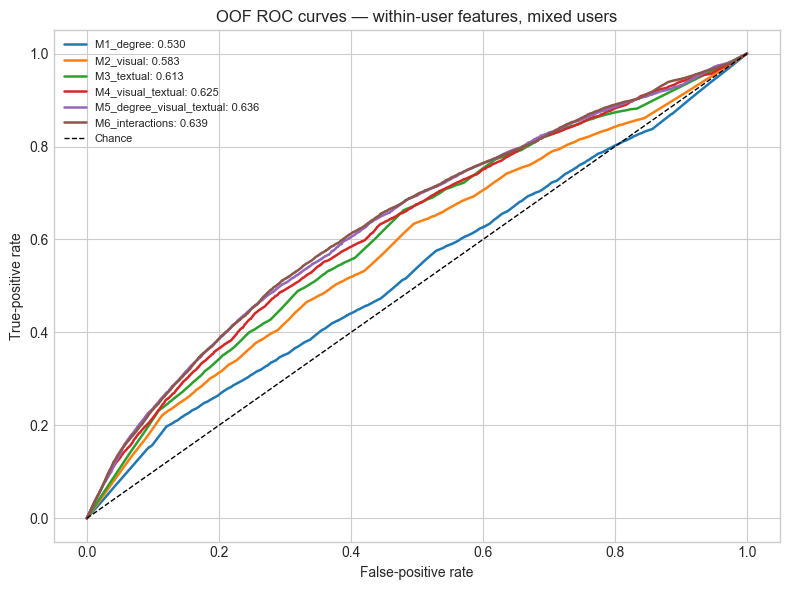

In [14]:
primary_labels = experiment_labels['within_mixed']
primary_predictions = oof_predictions['within_mixed']

fig, axis = plt.subplots(figsize=(8, 6))
for model_name in MAIN_MODELS[1:]:
    false_positive_rate, true_positive_rate, _ = roc_curve(
        primary_labels, primary_predictions[model_name]
    )
    auc_value = roc_auc_score(primary_labels, primary_predictions[model_name])
    axis.plot(false_positive_rate, true_positive_rate, linewidth=1.8, label=f'{model_name}: {auc_value:.3f}')

axis.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='Chance')
axis.set(
    xlabel='False-positive rate', ylabel='True-positive rate',
    title='OOF ROC curves — within-user features, mixed users',
)
axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Macro within-user AUC and user bootstrap

Pooled AUC can compare a selected edge from one user with an unselected edge from another. Macro user AUC instead computes discrimination separately inside every mixed user, then averages users equally. Bootstrap confidence intervals resample users, not individual edges.

In [18]:
def fast_binary_auc(labels, scores):
    labels = np.asarray(labels, dtype=np.int8)
    scores = np.asarray(scores, dtype=np.float64)
    positive = labels.sum()
    negative = len(labels) - positive
    if positive == 0 or negative == 0:
        return np.nan
    ranks = rankdata(scores, method='average')
    positive_rank_sum = ranks[labels.astype(bool)].sum()
    return (positive_rank_sum - positive * (positive + 1) / 2.0) / (positive * negative)

primary_data = experiment_data['within_mixed']
user_auc_rows = []
for user_id, positions in primary_data.groupby('user_id', sort=False).indices.items():
    positions = np.asarray(positions)
    labels = primary_labels[positions]
    row = {
        'user_id': user_id,
        'edges': len(positions),
        'selected_edges': int(labels.sum()),
    }
    for model_name in MODEL_FEATURES:
        row[model_name] = fast_binary_auc(
            labels, primary_predictions[model_name][positions]
        )
    user_auc_rows.append(row)

user_auc_df = pd.DataFrame(user_auc_rows)
assert user_auc_df[list(MODEL_FEATURES)].notna().all().all()

macro_user_auc = pd.DataFrame({
    'mean_user_auc': user_auc_df[MAIN_MODELS].mean(),
    'median_user_auc': user_auc_df[MAIN_MODELS].median(),
    'fraction_users_auc_above_0_5': user_auc_df[MAIN_MODELS].gt(0.5).mean(),
    'users': len(user_auc_df),
}).reindex(MAIN_MODELS)
macro_user_auc

,mean_user_auc,median_user_auc,fraction_users_auc_above_0_5,users
M0,0.500000,0.500000,0.000000,12922
M1_degree,0.530685,0.500000,0.462544,12922
M2_visual,0.594437,0.625000,0.552778,12922
M3_textual,0.629051,0.666667,0.600217,12922
M4_visual_textual,0.632593,0.666667,0.601687,12922
M5_degree_visual_textual,0.646683,0.666667,0.626296,12922
M6_interactions,0.646825,0.666667,0.627148,12922


In [19]:
rng = np.random.default_rng(SEED)
bootstrap_rows = []
n_bootstrap_users = len(user_auc_df)

for label, (larger, reference) in contrast_specs.items():
    per_user_difference = (user_auc_df[larger] - user_auc_df[reference]).to_numpy()
    bootstrapped_mean = np.empty(N_BOOTSTRAP, dtype=np.float64)
    for bootstrap_index in range(N_BOOTSTRAP):
        sampled_positions = rng.integers(0, n_bootstrap_users, size=n_bootstrap_users)
        bootstrapped_mean[bootstrap_index] = per_user_difference[sampled_positions].mean()
    ci_low, ci_high = np.quantile(bootstrapped_mean, [0.025, 0.975])
    bootstrap_rows.append({
        'contrast': label,
        'mean_user_delta_auc': per_user_difference.mean(),
        'median_user_delta_auc': np.median(per_user_difference),
        'bootstrap_ci_low': ci_low,
        'bootstrap_ci_high': ci_high,
        'fraction_users_positive_delta': (per_user_difference > 0).mean(),
        'users': n_bootstrap_users,
    })

user_bootstrap_contrasts = pd.DataFrame(bootstrap_rows).set_index('contrast')
user_bootstrap_contrasts

,mean_user_delta_auc,median_user_delta_auc,bootstrap_ci_low,bootstrap_ci_high,fraction_users_positive_delta,users
contrast,,,,,,
Affinity pair vs degree,0.101908,0.000000,0.096346,0.107605,0.483439,12922
Textual vs visual,0.034613,0.000000,0.028071,0.041024,0.401254,12922
Degree after affinities,0.014090,0.000000,0.010864,0.017166,0.275422,12922
Interactions after main effects,0.000143,0.000000,-0.001385,0.001694,0.113682,12922
Visual conditional contribution,0.013748,0.000000,0.010230,0.017012,0.277589,12922
Textual conditional contribution,0.052209,0.000000,0.046869,0.057043,0.387247,12922


## 5. Standardized coefficients with user-clustered uncertainty

The primary cohort is refit on all available mixed-user edges after standardization. The covariance below is a user-clustered sandwich estimate. Because scikit-learn is fit with `C=1e6`, the tiny remaining penalty is ignored in the covariance approximation.

In [20]:
def fit_full_standardized_model(base, labels, model_name):
    scaler = StandardScaler().fit(base[['D', 'V', 'T']])
    design = standardized_design(base, scaler)
    columns = MODEL_FEATURES[model_name]
    model = make_logistic()
    model.fit(design[columns], labels)
    return scaler, design, model

def clustered_coefficient_table(model, design, columns, labels, groups):
    x = design[columns].to_numpy(dtype=np.float64)
    x_with_intercept = np.column_stack([np.ones(len(x)), x])
    probability = model.predict_proba(x)[:, 1]
    residual = labels - probability
    weights = np.clip(probability * (1.0 - probability), 1e-12, None)

    information = x_with_intercept.T @ (x_with_intercept * weights[:, None])
    bread = np.linalg.pinv(information)

    observation_scores = x_with_intercept * residual[:, None]
    score_frame = pd.DataFrame(observation_scores)
    score_frame['cluster'] = np.asarray(groups)
    cluster_scores = score_frame.groupby('cluster', sort=False).sum().to_numpy()
    meat = cluster_scores.T @ cluster_scores

    n_observations, n_parameters = x_with_intercept.shape
    n_clusters = len(cluster_scores)
    correction = (n_clusters / (n_clusters - 1.0)) * (
        (n_observations - 1.0) / (n_observations - n_parameters)
    )
    covariance = correction * bread @ meat @ bread
    standard_error = np.sqrt(np.clip(np.diag(covariance), 0.0, None))

    coefficient = np.concatenate([model.intercept_, model.coef_.ravel()])
    z_value = coefficient / standard_error
    p_value = 2.0 * norm.sf(np.abs(z_value))
    ci_low = coefficient - 1.96 * standard_error
    ci_high = coefficient + 1.96 * standard_error

    return pd.DataFrame({
        'term': ['intercept', *columns],
        'coefficient': coefficient,
        'clustered_se': standard_error,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'odds_ratio': np.exp(coefficient),
        'odds_ratio_ci_low': np.exp(ci_low),
        'odds_ratio_ci_high': np.exp(ci_high),
        'p_value': p_value,
    })

In [21]:
primary_base = experiment_base['within_mixed']
primary_groups = experiment_data['within_mixed'].user_id.to_numpy()
full_fit_objects = {}
coefficient_frames = []

for model_name in ['M5_degree_visual_textual', 'M6_interactions']:
    scaler, design, model = fit_full_standardized_model(
        primary_base, primary_labels, model_name
    )
    full_fit_objects[model_name] = {
        'scaler': scaler, 'design': design, 'model': model
    }
    table = clustered_coefficient_table(
        model, design, MODEL_FEATURES[model_name],
        primary_labels, primary_groups,
    )
    table.insert(0, 'model', model_name)
    coefficient_frames.append(table)

coefficient_summary = pd.concat(coefficient_frames, ignore_index=True)
coefficient_summary.set_index(['model', 'term'])

c:\Users\vulam\miniconda3\envs\explainable\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\vulam\miniconda3\envs\explainable\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


coefficient  clustered_se    ci_low  \
model                    term                                             
M5_degree_visual_textual intercept    -0.705877      0.011341 -0.728106   
                         D             0.228350      0.009913  0.208920   
                         V             0.265711      0.008509  0.249035   
                         T             0.445681      0.009185  0.427678   
M6_interactions          intercept    -0.742597      0.012789 -0.767663   
                         D             0.234820      0.010227  0.214776   
                         V             0.266786      0.008672  0.249789   
                         T             0.445991      0.009217  0.427925   
                         D_x_V        -0.095733      0.008242 -0.111888   
                         D_x_T         0.009714      0.008466 -0.006880   

                                     ci_high  odds_ratio  odds_ratio_ci_low  \
model                    term                                                 
M5_degree_visual_textual intercept -0.683648    0.493675           0.482823   
                         D          0.247780    1.256525           1.232346   
                         V          0.282388    1.304359           1.282787   
                         T          0.463683    1.561553           1.533693   
M6_interactions          intercept -0.717531    0.475876           0.464096   
                         D          0.254864    1.264681           1.239584   
                         V          0.283784    1.305761           1.283754   
                         T          0.464056    1.562037           1.534071   
                         D_x_V     -0.079578    0.908707           0.894144   
                         D_x_T      0.026307    1.009761           0.993144   

                                    odds_ratio_ci_high  p_value  
model                    term                                    
M5_degree_visual_textual intercept            0.504772 0.000000  
                         D                    1.281178 0.000000  
                         V                    1.326293 0.000000  
                         T                    1.589920 0.000000  
M6_interactions          intercept            0.487955 0.000000  
                         D                    1.290286 0.000000  
                         V                    1.328146 0.000000  
                         T                    1.590512 0.000000  
                         D_x_V                0.923506 0.000000  
                         D_x_T                1.026656 0.251226

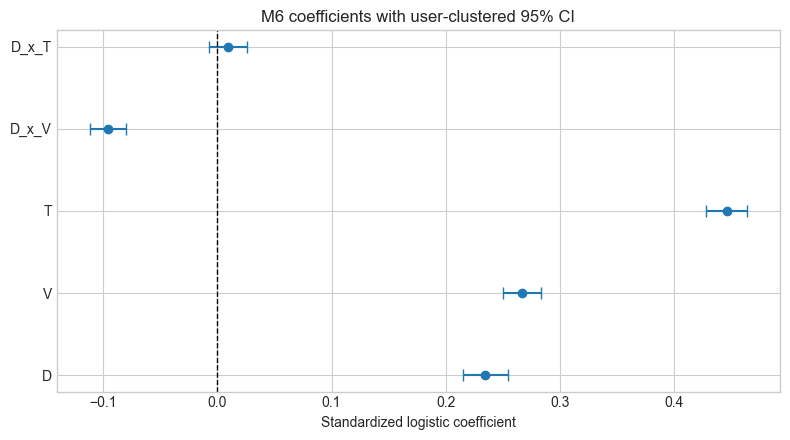

In [22]:
plot_coefficients = coefficient_summary.loc[
    coefficient_summary.model.eq('M6_interactions')
    & coefficient_summary.term.ne('intercept')
].copy()

fig, axis = plt.subplots(figsize=(8, 4.5))
positions = np.arange(len(plot_coefficients))
axis.errorbar(
    plot_coefficients.coefficient, positions,
    xerr=[
        plot_coefficients.coefficient - plot_coefficients.ci_low,
        plot_coefficients.ci_high - plot_coefficients.coefficient,
    ],
    fmt='o', capsize=4, color='tab:blue',
)
axis.axvline(0, color='black', linestyle='--', linewidth=1)
axis.set_yticks(positions, plot_coefficients.term)
axis.set(
    xlabel='Standardized logistic coefficient',
    title='M6 coefficients with user-clustered 95% CI',
)
plt.tight_layout()
plt.show()

## 6. Interaction curves

Each panel varies degree percentile from 0 to 1. The focal affinity is fixed at P10, P50, or P90, while the other modality is held at its median percentile (0.5). These are model-implied associations, not causal effects.

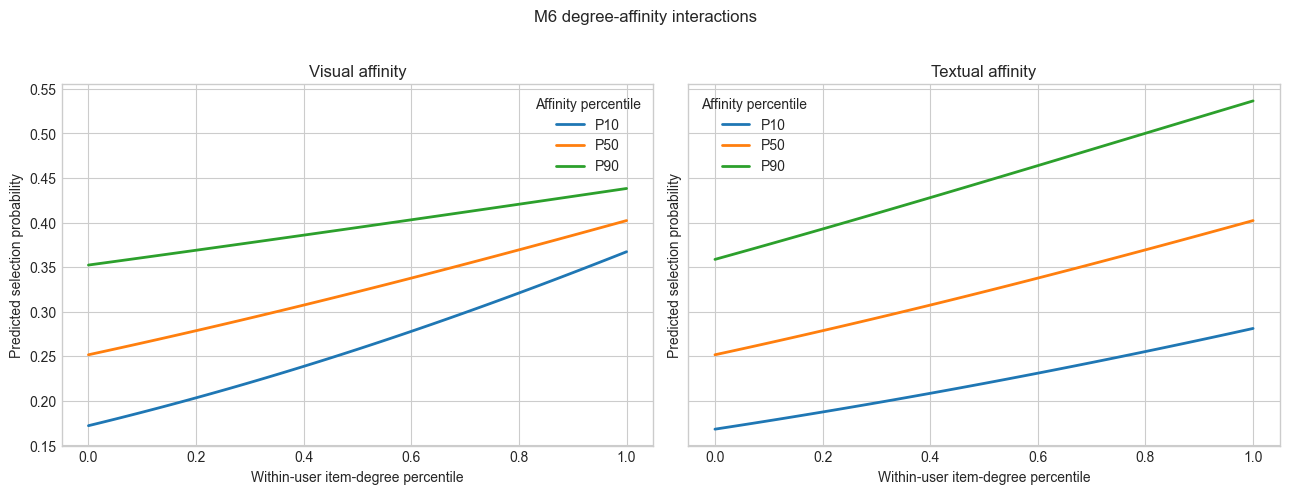

In [23]:
m6_fit = full_fit_objects['M6_interactions']
m6_columns = MODEL_FEATURES['M6_interactions']
degree_grid = np.linspace(0.0, 1.0, 101)
affinity_levels = OrderedDict([('P10', 0.1), ('P50', 0.5), ('P90', 0.9)])

def predict_interaction_curve(focal_modality, focal_value):
    raw_base = pd.DataFrame({
        'D': degree_grid,
        'V': np.full_like(degree_grid, 0.5),
        'T': np.full_like(degree_grid, 0.5),
    })
    raw_base[focal_modality] = focal_value
    design = standardized_design(raw_base, m6_fit['scaler'])
    return m6_fit['model'].predict_proba(design[m6_columns])[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for axis, focal_modality, modality_label in [
    (axes[0], 'V', 'Visual affinity'),
    (axes[1], 'T', 'Textual affinity'),
]:
    for level_name, level_value in affinity_levels.items():
        probability = predict_interaction_curve(focal_modality, level_value)
        axis.plot(degree_grid, probability, linewidth=2, label=level_name)
    axis.set(
        xlabel='Within-user item-degree percentile',
        ylabel='Predicted selection probability',
        title=modality_label,
    )
    axis.legend(title='Affinity percentile')

fig.suptitle('M6 degree-affinity interactions', y=1.02)
plt.tight_layout()
plt.show()

## 7. Robustness across feature scope and cohort

The primary result is `within_mixed`. Differences between `within_mixed` and `within_all` show how homogeneous-label users affect the conclusion; differences between `within_*` and `global_*` show the effect of using relative versus absolute features.

In [24]:
robustness_auc = (
    performance_summary.loc[performance_summary.model.isin(MAIN_MODELS)]
    .pivot(index='experiment', columns='model', values='pooled_roc_auc')
    .reindex(index=[spec['name'] for spec in experiment_specs], columns=MAIN_MODELS)
)
robustness_auc

model,M0,M1_degree,M2_visual,M3_textual,M4_visual_textual,M5_degree_visual_textual,M6_interactions
experiment,,,,,,,
within_mixed,0.494197,0.529728,0.582945,0.613455,0.625142,0.636226,0.638665
global_mixed,0.494197,0.567750,0.664334,0.708808,0.719621,0.727268,0.732111
within_all,0.497037,0.522837,0.562625,0.585956,0.596059,0.604616,0.606680
global_all,0.497037,0.599325,0.678860,0.727118,0.736970,0.738858,0.743693


## 8. Interpretation checklist

Use the following evidence jointly:

- Affinity dominates degree if M4 substantially exceeds M1 and M5 adds little over M4.
- Textual affinity dominates visual affinity if M3 exceeds M2 and the textual drop-one contribution exceeds the visual contribution.
- Degree is mainly a confounder if M1 has signal but its standardized M5 coefficient and M5-minus-M4 AUC are small after controlling affinity.
- Popularity is conditionally accepted when `D_x_T` is positive, its clustered CI excludes zero, M6 improves on M5, and the textual P90 curve rises more strongly with degree than the P10 curve.
- Statistical significance alone is insufficient with more than 100,000 edges; prioritize effect size, delta AUC, bootstrap CI, and consistency across robustness settings.

The affinities and mask were learned jointly from the same checkpoint. Even grouped out-of-fold prediction therefore measures explanatory association with the learned state, not prospective prediction from independently measured covariates.

In [ ]:
SAVE_RESULTS = False
if SAVE_RESULTS:
    output_dir = SRC_DIR / 'mask_analysis' / 'logistic_results'
    output_dir.mkdir(parents=True, exist_ok=True)
    performance_summary.to_csv(output_dir / 'performance_summary.csv', index=False)
    pooled_contrasts.to_csv(output_dir / 'pooled_auc_contrasts.csv')
    macro_user_auc.to_csv(output_dir / 'macro_user_auc.csv')
    user_bootstrap_contrasts.to_csv(output_dir / 'user_bootstrap_contrasts.csv')
    coefficient_summary.to_csv(output_dir / 'coefficient_summary.csv', index=False)
    robustness_auc.to_csv(output_dir / 'robustness_auc.csv')
    print('Saved results to:', output_dir)
else:
    print('Set SAVE_RESULTS = True to export result tables.')